In [1]:
import pandas as pd
import numpy as np
import os
import netCDF4 as nc  
import matplotlib.pyplot as plt
import plotly.express as px
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import plotly.graph_objects as go
from sklearn.decomposition import PCA
from ripser import Rips
rips = Rips(maxdim=1)
import pickle
from tqdm import tqdm
from datetime import datetime
import scipy.io
import seaborn as sns
import warnings
from shapely.errors import ShapelyDeprecationWarning
import sys
import importlib
import tcripser as tcr

Rips(maxdim=1, thresh=inf, coeff=2, do_cocycles=False, n_perm = None, verbose=True)


In [2]:
# Get the path of the notebook file
notebook_path = os.getcwd()

# Directory containing the notebook file
notebook_directory = os.path.dirname(notebook_path)
notebook_directory

'/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate'

In [3]:
sys.path.append(os.path.join(notebook_directory, 'src'))
import cubical_pers_and_filt_visual, globe_visualization,feature_tracking

importlib.reload(cubical_pers_and_filt_visual)
importlib.reload(globe_visualization)
importlib.reload(feature_tracking)

<module 'feature_tracking' from '/Users/himanshuyadav/UF Dropbox/Himanshu Yadav/files/PhD_TDA/Climate/src/feature_tracking.py'>

In [4]:
lat_cut = [[0,90]]
lon_cut = [[0,360]]

# Analysis

## Load persistence information for Cubical Persistence of Sub and Sup regions of SLP-anomaly

In [5]:
# # Create directory if it doesn't exist
# persistence_dir = os.path.join(notebook_directory, 'data', 'processed_data', 'persistence_data')
# os.makedirs(persistence_dir, exist_ok=True)

# persistences_positive = feature_tracking.get_persistence_by_year_day('sub', notebook_directory, 1948, 2023)
# persistences_negative = feature_tracking.get_persistence_by_year_day('sup', notebook_directory, 1948, 2023)

# # Save positive persistence dictionary
# with open(os.path.join(persistence_dir, 'persistences_posititve_CR.pkl'), 'wb') as file:
#     pickle.dump(persistences_positive, file)

# # Save negative persistence dictionary  
# with open(os.path.join(persistence_dir, 'persistences_negative_CR.pkl'), 'wb') as file:
#     pickle.dump(persistences_negative, file)

In [6]:
# Load the dictionary from the pickle file
with open(notebook_directory+'/data/processed_data/persistence_data/persistences_posititve_CR.pkl', 'rb') as file:
    loaded_persistences_sub = pickle.load(file)

# Load the dictionary from the pickle file
with open(notebook_directory+'/data/processed_data/persistence_data/persistences_negative_CR.pkl', 'rb') as file:
    loaded_persistences_sup = pickle.load(file)

In [7]:
# Function to calculate means of the inner lists
def calculate_sums(nested_list):
    return [np.sum(sublist) for sublist in nested_list]

def calculate_sums_second_order(nested_list):
    return [np.sum(np.array(sublist)**2) for sublist in nested_list]

def find_anomalies_per(df_column):
    # Convert the Series of lists to a 2D numpy array
    # Each row represents a year, each column represents the same day across years
    data_array = np.array(df_column.tolist())

    # Calculate the average for each day across all years
    daily_averages = np.mean(data_array, axis=0)

    # Subtract the daily average from each corresponding day
    anomalies = data_array - daily_averages

    # Convert back to list of lists format
    return [list(year_data) for year_data in anomalies]

In [8]:
# Convert dictionary to DataFrame
per_sub_df = pd.DataFrame(list(loaded_persistences_sub.items()), columns=['Year', 'Persistences'])
# Apply the function to each element in the 'Persistences' column to create the new 'Means' column
per_sub_df['total_persistence'] = per_sub_df['Persistences'].apply(calculate_sums)
per_sub_df["anomaly_total_per"] = find_anomalies_per(per_sub_df.total_persistence)
per_sub_df['total_persistence_2'] = per_sub_df['Persistences'].apply(calculate_sums_second_order)
per_sub_df["anomaly_total_per_2"] = find_anomalies_per(per_sub_df.total_persistence_2)

In [9]:
# Convert dictionary to DataFrame
per_sup_df = pd.DataFrame(list(loaded_persistences_sup.items()), columns=['Year', 'Persistences'])
# Apply the function to each element in the 'Persistences' column to create the new 'Means' column
per_sup_df['total_persistence'] = per_sup_df['Persistences'].apply(calculate_sums)
per_sup_df["anomaly_total_per"] = find_anomalies_per(per_sup_df.total_persistence)
per_sup_df['total_persistence_2'] = per_sup_df['Persistences'].apply(calculate_sums_second_order)
per_sup_df["anomaly_total_per_2"] = find_anomalies_per(per_sup_df.total_persistence_2)

### Slicing df to match time for other climate indices

In [10]:
num_of_years = 2022 - 1950 + 1
num_of_days = num_of_years * 365
num_of_years, num_of_days

(73, 26645)

In [11]:
per_sub_df = per_sub_df[2:75]
per_sup_df = per_sup_df[2:75]
sub_anomaly_total_per_list = np.array(per_sub_df.anomaly_total_per.to_list()).flatten() / 100
sup_anomaly_total_per_list = np.array(per_sup_df.anomaly_total_per.to_list()).flatten() / 100
sub_total_per_list = np.array(per_sub_df.total_persistence.to_list()).flatten() / 100
sup_total_per_list = np.array(per_sup_df.total_persistence.to_list()).flatten() / 100

sub_anomaly_total_per_2_list = np.array(per_sub_df.anomaly_total_per_2.to_list()).flatten() / 100**2
sup_anomaly_total_per_2_list = np.array(per_sup_df.anomaly_total_per_2.to_list()).flatten() / 100**2
sub_total_per_2_list = np.array(per_sub_df.total_persistence_2.to_list()).flatten() / 100**2
sup_total_per_2_list = np.array(per_sup_df.total_persistence_2.to_list()).flatten() / 100**2

## Loading climate indices

### Daily climate indices

In [12]:
# entry from 1 Jan 1950 to 31 Dec 2024
mat_indices = scipy.io.loadmat(notebook_directory+'/data/raw/Several_Atmospheric_Indices_since1950.mat')

In [13]:
# Extract the arrays from mat_indices
dates = mat_indices['Dates_all'][0][:num_of_days]  # Remove the extra dimension
amo = mat_indices['AMO_daily'][0][:num_of_days] 
ea = mat_indices['EA_daily_detrend'][0][:num_of_days] 
enso = mat_indices['ENSO_daily'][0][:num_of_days] 
nao = mat_indices['NAO_daily'][0][:num_of_days] 
pdo = mat_indices['PDO_daily'][0][:num_of_days] 
scand = mat_indices['SCAND_daily'][0][:num_of_days] 

In [14]:
# Convert date integers to datetime objects
datetime_dates = []
for date_int in dates:
    year = int(date_int // 10000)
    month = int((date_int % 10000) // 100)
    day = int(date_int % 100)
    datetime_dates.append(datetime(year, month, day))

In [15]:
# Create DataFrame
indices_df_daily = pd.DataFrame({
    'Date': datetime_dates,
    'AMO': amo,
    'EA': ea,
    'ENSO': enso,
    'NAO': nao,
    'PDO': pdo,
    'SCAND': scand,
    'sub_total_per_anomaly': sub_anomaly_total_per_list,
    'sup_total_per_anomaly': sup_anomaly_total_per_list,
    'sub_total_per': sub_total_per_list,
    'sup_total_per': sup_total_per_list,
    'sub_total_per_2_anomaly': sub_anomaly_total_per_2_list,
    'sup_total_per_2_anomaly': sup_anomaly_total_per_2_list,
    'sub_total_per_2': sub_total_per_2_list,
    'sup_total_per_2': sup_total_per_2_list,
})

# Set the 'Date' column as the index
indices_df_daily.set_index('Date', inplace=True)

### Monthly climate indices

In [16]:
# Resample to monthly frequency
monthly_df = indices_df_daily[['AMO', 'EA', 'ENSO', 'NAO', 'PDO', 'SCAND',
                                'sub_total_per_anomaly', 'sup_total_per_anomaly',
                                'sub_total_per', 'sup_total_per',
                                'sub_total_per_2_anomaly', 'sup_total_per_2_anomaly',
                                'sub_total_per_2', 'sup_total_per_2']].resample('MS').mean()

## Analysis of Monthly climate indices

In [17]:
def plot_column(df, column_name, figsize=(12, 6), label_fontsize=12, tick_fontsize=10,diff = False):
    """
    Create a simple black and white plot of a specified column from a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        The DataFrame containing the data with a DatetimeIndex
    column_name : str
        The name of the column to plot
    figsize : tuple, optional
        The figure size (width, height) in inches
    label_fontsize : int, optional
        Font size for the axis labels
    tick_fontsize : int, optional
        Font size for the tick labels
    
    Returns:
    --------
    The matplotlib plot object ready for display
    """
    
    # Create figure and axis
    plt.figure(figsize=figsize)
    
    # Plot the data with a simple black line
    plt.plot(df.index, df[column_name], color='black', linewidth=1.5)
    
    plt.xlabel("Year", fontsize=label_fontsize)
    if diff:
        plt.ylabel(r'TP$_{1}$' +'(hPa)', fontsize=label_fontsize)
    else:
        plt.ylabel(column_name, fontsize=label_fontsize)
    
    # Increase tick label font size
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    
    # Remove grid
    plt.grid(False)
    # Format the date axis
    plt.gcf().autofmt_xdate()
    
    plt.tight_layout()
    return plt

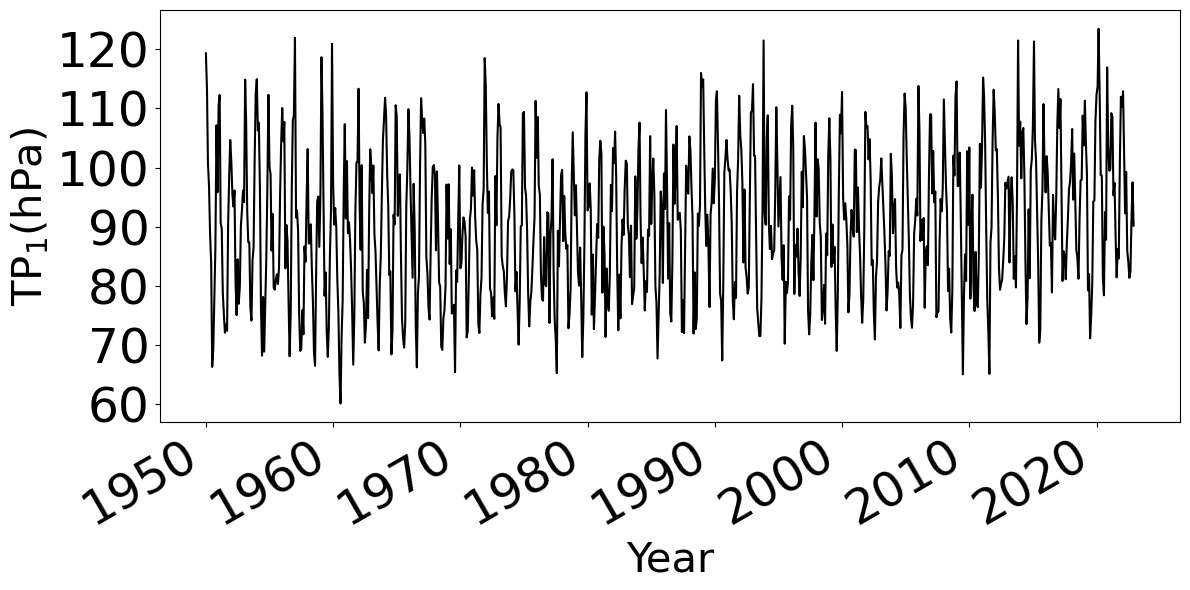

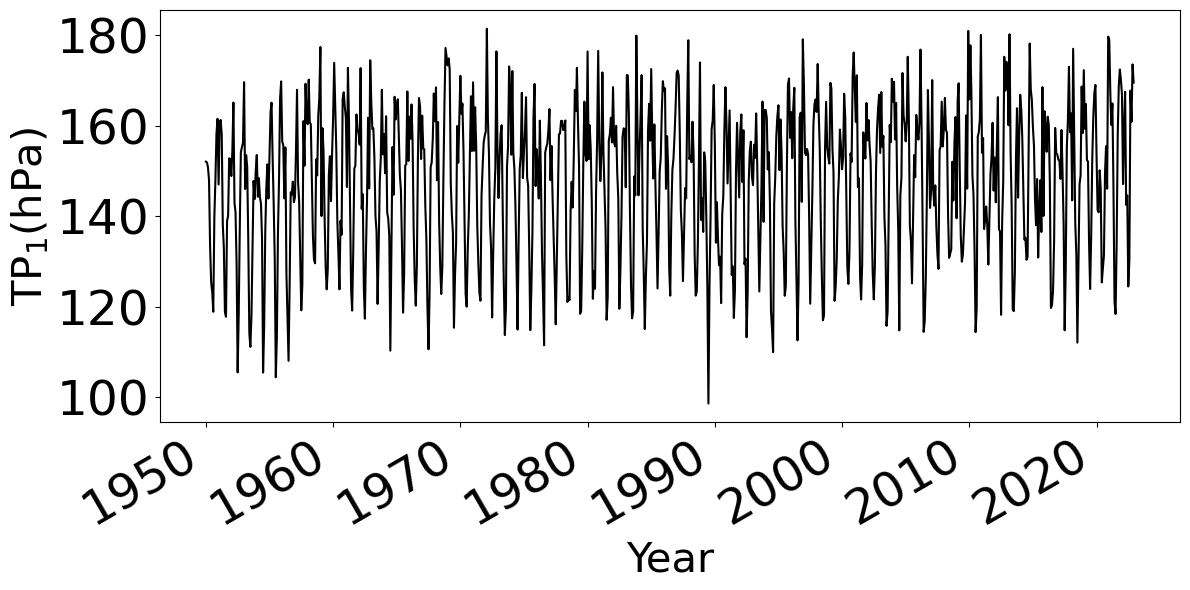

In [18]:
for col in ['sub_total_per','sup_total_per']:
    plot_column(monthly_df,col,label_fontsize=30,tick_fontsize=35,diff=True)
    plt.savefig(notebook_directory+"/output/figures/monthly_charts/"+col+"_monthly_chart.png", dpi=500, bbox_inches='tight')  # PNG format
    plt.show()

In [19]:
# for col in ['AMO', 'EA', 'ENSO', 'NAO', 'PDO', 'SCAND']:
#     plot_column(monthly_df,col,label_fontsize=35,tick_fontsize=35)
#     plt.savefig(notebook_directory+"/output/figures/monthly_charts/"+col+"_monthly_chart.png", dpi=500, bbox_inches='tight')  # PNG format
#     #plt.show()

In [20]:
def plot_two_columns(df, col1, col2, figsize=(12, 6),
                     label_fontsize=12, tick_fontsize=10,
                     diff=False, year_step=5,
                     label1=r'TPM$_C$', label2=r'TPM$_A$'):
    """
    Plot two columns on the same figure with simplified year ticks
    and custom labels for each column.
    """

    plt.figure(figsize=figsize)

    # Plot col2 (solid black)
    plt.plot(df.index, df[col2], color='black', linestyle='-', linewidth=1.8,
             label=label2)

    # Plot col1 (dashed black)
    plt.plot(df.index, df[col1], color='black', linestyle='--', linewidth=1.8,
             label=label1)

    

    # Axis labels
    plt.xlabel("Year", fontsize=label_fontsize)
    if diff:
        plt.ylabel("Total Topological Depth (hPa)", fontsize=label_fontsize)
    else:
        plt.ylabel("Value", fontsize=label_fontsize)

    # Tick font sizes
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)

    # Remove grid
    plt.grid(False)

    # Year tick simplification
    years = sorted(df.index.year.unique())
    selected_years = years[::year_step]

    # Corresponding datetime positions
    year_positions = [df.index[df.index.year == y][0] for y in selected_years]

    plt.xticks(year_positions, [str(y) for y in selected_years],
               fontsize=tick_fontsize)

    #plt.legend(fontsize=label_fontsize)

    plt.tight_layout()
    return plt


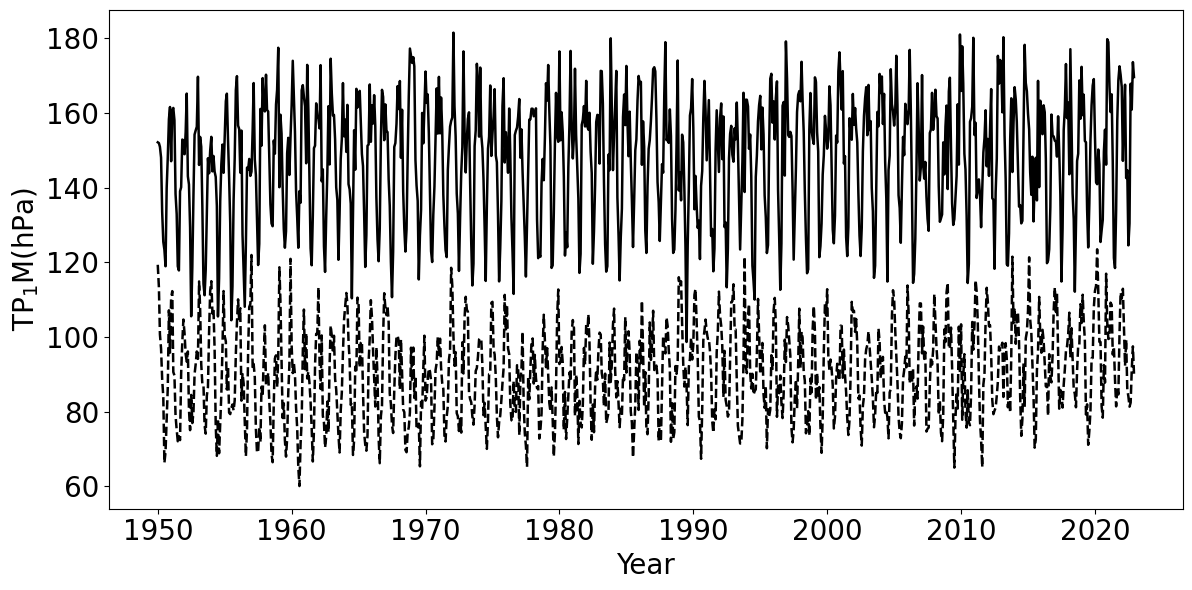

In [27]:
plot_two_columns(
    monthly_df,
    'sub_total_per',
    'sup_total_per',
    label_fontsize=20,
    tick_fontsize=20,
    diff=True,
    year_step=10,
    label1='TPM$_A$',
    label2='TPM$_C$',
)
plt.ylabel(r'TP$_{1}$M' +'(hPa)', fontsize=20)
plt.savefig(notebook_directory + "/output/figures/TP_average_monthly.png",dpi=300, bbox_inches='tight')
plt.show()

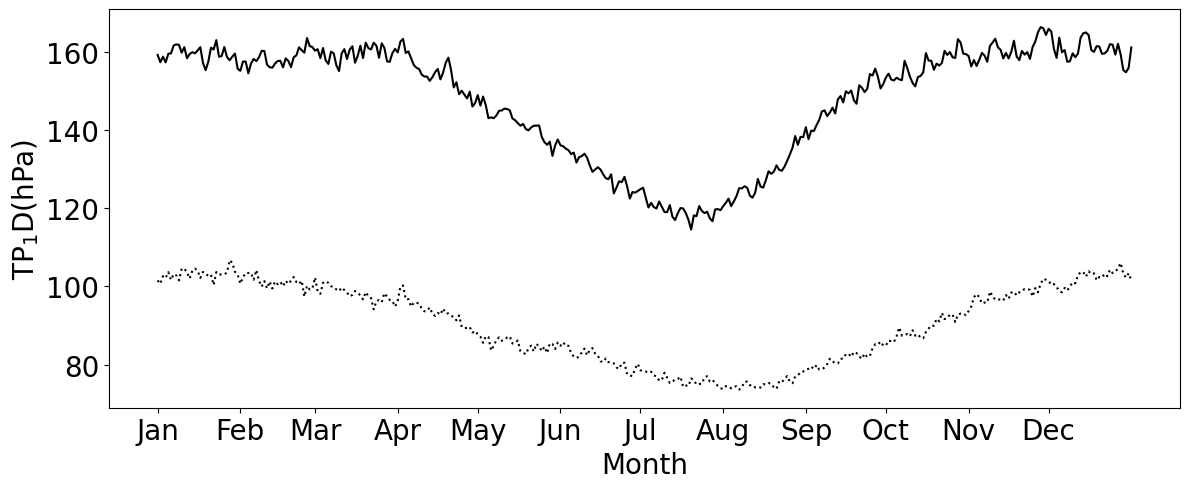

In [30]:
# Day-of-year average plot
doy_df = indices_df_daily[['sub_total_per', 'sup_total_per']].copy()
doy_df['doy'] = doy_df.index.dayofyear
doy_mean = doy_df.groupby('doy').mean()

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(doy_mean.index, doy_mean['sup_total_per'], color='black', linestyle='-',
        linewidth=1.5, label=r'TPD$_C$ average')
ax.plot(doy_mean.index, doy_mean['sub_total_per'], color='black', linestyle=':',
        linewidth=1.5, label=r'TPD$_A$ average')

fs = 20
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=fs)
ax.set_xlabel('Month', fontsize=fs)
ax.set_ylabel(r'TP$_{1}$D' +'(hPa)', fontsize=fs)
ax.tick_params(axis='y', labelsize=fs)
#ax.legend(fontsize=fs, frameon=True)
ax.grid(False)
plt.tight_layout()
plt.savefig(notebook_directory + "/output/figures/TP_average.png", dpi=300, bbox_inches='tight')
plt.show()


## Second Order Total Persistence

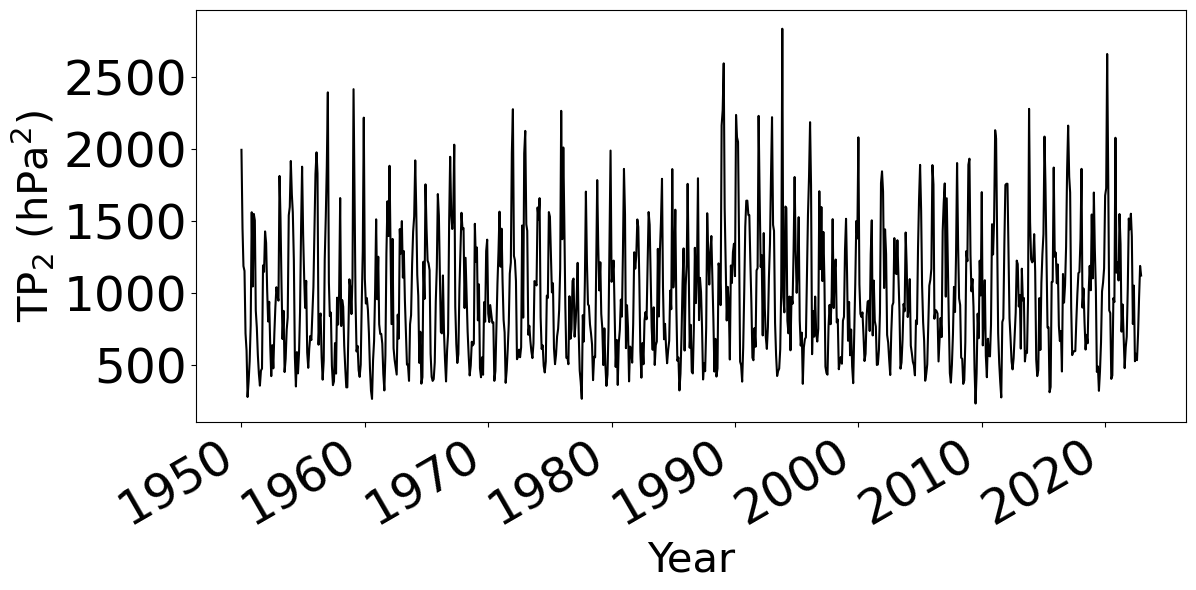

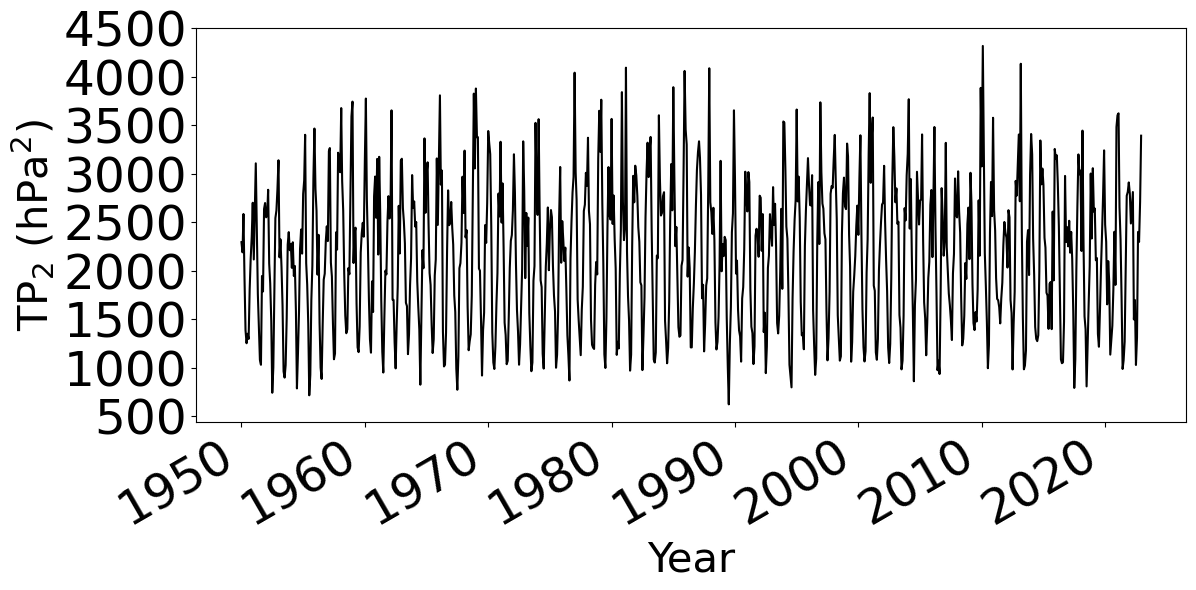

In [23]:
for col in ['sub_total_per_2', 'sup_total_per_2']:
    plot_column(monthly_df, col, label_fontsize=30, tick_fontsize=35, diff=True)
    plt.ylabel(r'TP$_{2}$' +" " + r'(hPa$^{2}$)', fontsize=30)
    plt.savefig(notebook_directory + "/output/figures/monthly_charts/" + col + "_monthly_chart.png", dpi=500, bbox_inches='tight')
    plt.show()

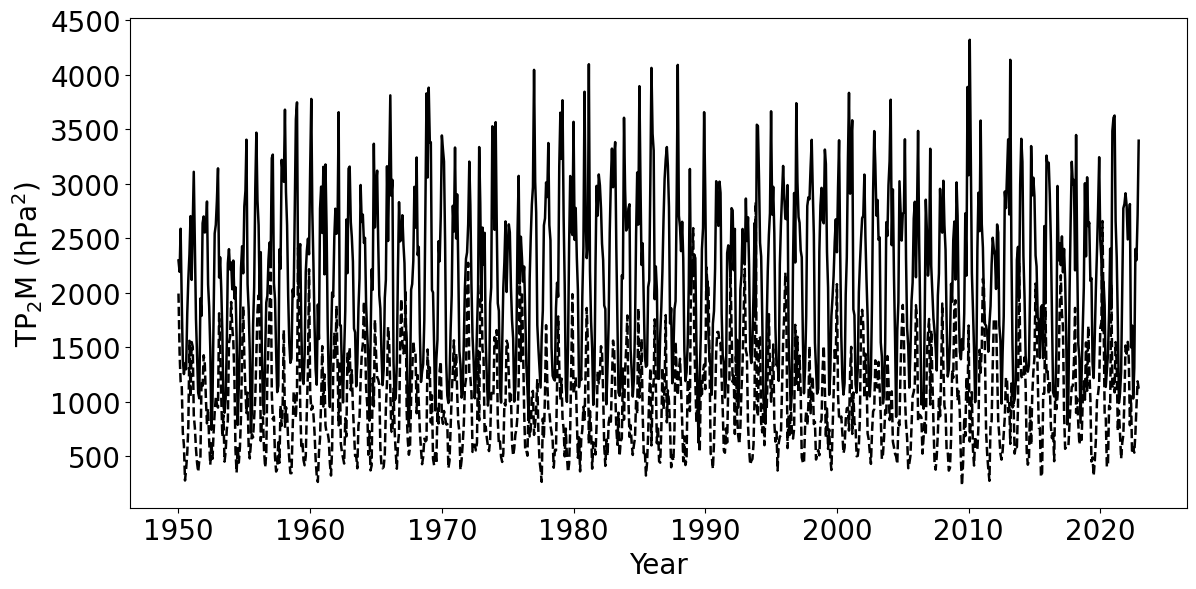

In [29]:
plot_two_columns(
    monthly_df,
    'sub_total_per_2',
    'sup_total_per_2',
    label_fontsize=20,
    tick_fontsize=20,
    diff=False,
    year_step=10,
    label1=r'TPM$^{(2)}_A$',
    label2=r'TPM$^{(2)}_C$',
)
plt.ylabel(r'TP$_{2}$M' +" " + r'(hPa$^{2}$)', fontsize=fs)
plt.savefig(notebook_directory + "/output/figures/TP2_average_monthly.png", dpi=300, bbox_inches='tight')
plt.show()

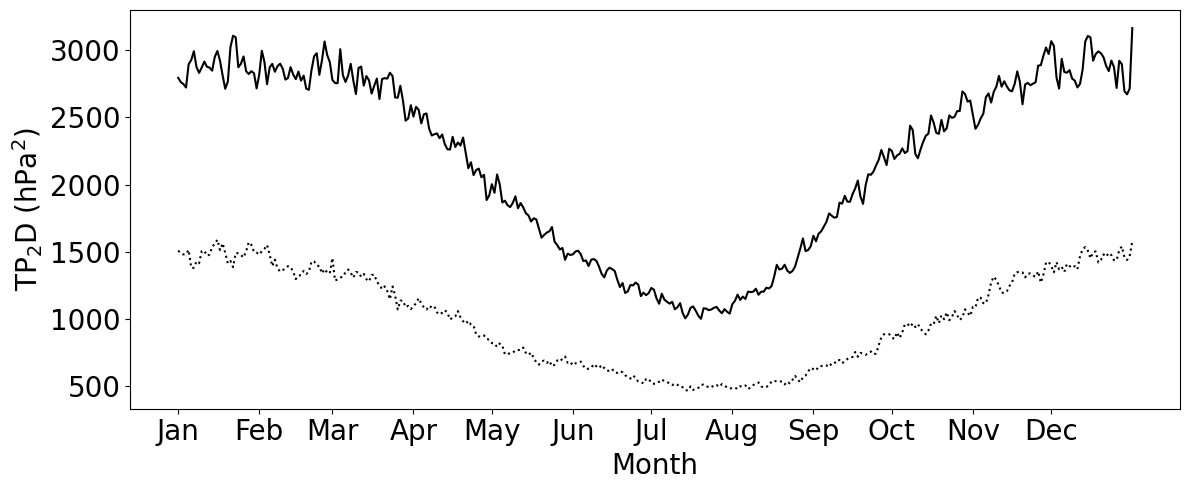

In [31]:
# Day-of-year average plot for second order total persistence
doy_df2 = indices_df_daily[['sub_total_per_2', 'sup_total_per_2']].copy()
doy_df2['doy'] = doy_df2.index.dayofyear
doy_mean2 = doy_df2.groupby('doy').mean()

month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(doy_mean2.index, doy_mean2['sup_total_per_2'], color='black', linestyle='-',
        linewidth=1.5, label=r'TPD$^{(2)}_C$ average')
ax.plot(doy_mean2.index, doy_mean2['sub_total_per_2'], color='black', linestyle=':',
        linewidth=1.5, label=r'TPD$^{(2)}_A$ average')

fs = 20
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels, fontsize=fs)
ax.set_xlabel('Month', fontsize=fs)
ax.set_ylabel(r'TP$_{2}$D' +" " + r'(hPa$^{2}$)', fontsize=fs)
ax.tick_params(axis='y', labelsize=fs)
ax.grid(False)
plt.tight_layout()
plt.savefig(notebook_directory + "/output/figures/TP2_average.png", dpi=300, bbox_inches='tight')
plt.show()